# 2. Pushbroom images

VELOX records one frame per second, and each frame covers several kilometres along the flight track, so consecutive frames overlap strongly. A pushbroom image cuts a narrow strip out of every frame -- as wide as the distance flown until the next frame -- and joins the strips into one continuous image along the track.

This notebook covers `velox_tools.processing.pushbroom` and its building blocks, and the one-call version `velox_tools.campaign.pushbroom`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

from velox_tools import campaign, processing

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']),
})

## Strip width

The strip width follows from the ground speed and the along-track pixel size, which `pixel_to_meter` derives from altitude and attitude:

In [2]:
t = slice('2024-08-25T12:30:00', '2024-08-25T12:30:09')
ds = campaign.load_velox(t, channels=3)
nav = campaign.interp_nav(campaign.load_nav(t), ds.time)

xlen, ylen = processing.pixel_to_meter(nav['pitch'], nav['roll'], nav['alt'])
rows = processing.compute_pixel_per_second(nav)
print(f'altitude:          {float(nav.alt.mean()):.0f} m')
print(f'frame footprint:   {float(xlen.mean()) / 1e3:.1f} km x {float(ylen.mean()) / 1e3:.1f} km')
print(f'pixel size:        {float(xlen.mean()) / 635:.1f} m x {float(ylen.mean()) / 507:.1f} m')
print(f'ground speed:      {float(nav.gs.mean()):.0f} m/s')
print(f'strip width:       {rows.min()} - {rows.max()} rows')

altitude:          13895 m
frame footprint:   8.9 km x 7.1 km
pixel size:        14.0 m x 14.1 m
ground speed:      241 m/s
strip width:       17 - 17 rows


The strips of three consecutive frames (`slicing_position=250`, the default). `processing.concat` does the cutting and joining on plain arrays:

pushbroom array of three frames: (635, 51)


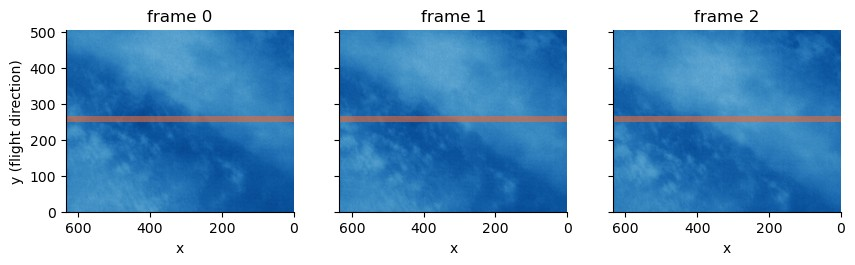

In [3]:
frames = ds['BT_2D'].isel(band=0, time=slice(0, 3)).values
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for i, ax in enumerate(axes):
    ax.imshow(frames[i].T, origin='lower', cmap='Blues', vmin=-40, vmax=10)
    ax.add_patch(Rectangle((0, 250), 634, rows[i], facecolor='#eb6834', alpha=0.6, edgecolor='none'))
    ax.set(title=f'frame {i}', xlabel='x')
    ax.invert_xaxis()
axes[0].set_ylabel('y (flight direction)')

strips = processing.concat(frames, 250, rows[:3])
print('pushbroom array of three frames:', strips.shape)

## One call

`campaign.pushbroom` loads the data and does the rest. Only the strip rows are read from disk, so a 13 minute segment of all five channels takes a few seconds:

In [4]:
pb = campaign.pushbroom(slice('2024-08-25T12:24', '2024-08-25T12:36'))
pb

Executed pushbroom in 2.3572 seconds


<xarray.Dataset> Size: 165MB
Dimensions:  (band: 5, y: 635, time: 12969)
Coordinates:
  * time     (time) datetime64[ns] 104kB 2024-08-25T12:23:58.126727775 ... 20...
  * y        (y) int64 5kB 0 1 2 3 4 5 6 7 8 ... 627 628 629 630 631 632 633 634
  * band     (band) int64 40B 1 2 3 5 6
Data variables:
    BT_2D    (band, y, time) float32 165MB -22.28 -22.53 ... -23.91 -24.04
Attributes:
    campaign:         PERCUSION
    research_flight:  RF07

In the output, `y` is the across-track pixel (`x` of the frames) and `time` runs along the track:

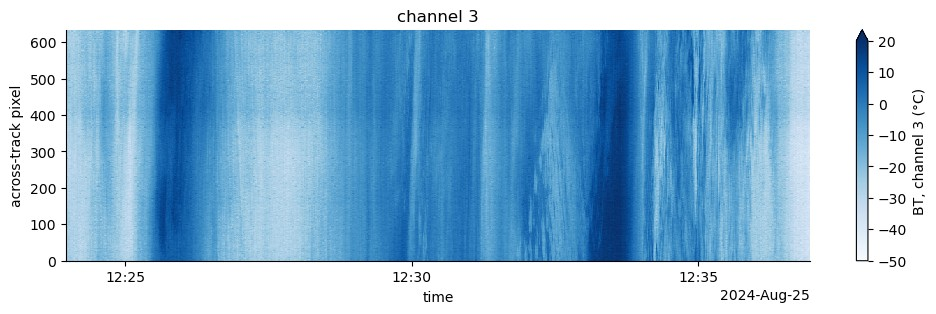

In [5]:
fig, ax = plt.subplots(figsize=(12, 3))
pb['BT_2D'].sel(band=3).plot.imshow(x='time', y='y', ax=ax, cmap='Blues', vmin=-50, vmax=20,
                                    cbar_kwargs=dict(label='BT, channel 3 (°C)'))
ax.set(ylabel='across-track pixel', title='channel 3');

## Building block

`processing.pushbroom` works on any dataset with frames `(time, x, y)` or `(band, time, x, y)` and navigation data with `pitch`, `roll`, `alt` and `gs` -- by default the BAHAMAS data of the flight. It pushbrooms every variable with at least three dimensions, e.g. after applying the fixed-pattern correction (notebook 4). `campaign.pushbroom` above is equivalent to:

In [6]:
t = slice('2024-08-25T12:30:00', '2024-08-25T12:30:59')
ds = campaign.load_velox(t, channels=[3, 6])
pb_own = processing.pushbroom(ds, slicing_position=250, nav_data=campaign.load_nav(t))
pb_own['BT_2D'].sizes

Executed pushbroom in 0.4278 seconds


Frozen({'band': 2, 'y': 635, 'time': 1003})

Pass `quality_flag` (one boolean per frame) to blank the strips of bad frames, e.g. `quality_flag=(abs(nav['roll']) < 5).values` to drop turns.

## Time axis

By default (`time_correction=True`), each column is labelled with the time the aircraft passes over the imaged ground, not the time the frame was taken. This matters when comparing with in-situ or nadir-pointing instruments. A strip far ahead of the nadir point makes the difference visible:

In [7]:
ahead = campaign.pushbroom(t, channels=3, slicing_position=400)
frame_time = campaign.pushbroom(t, channels=3, slicing_position=400, time_correction=False)
offset = (ahead.time.values - frame_time.time.values) / np.timedelta64(1, 's')
print(f'row 400 sees the ground {np.median(offset):.1f} s before the aircraft is overhead')

Executed pushbroom in 0.1700 seconds
Executed pushbroom in 0.1438 seconds
row 400 sees the ground 6.2 s before the aircraft is overhead


## Georeferenced pushbroom images

With `georef=True`, `campaign.pushbroom` adds latitude and longitude for every pixel. Only the strip rows are georeferenced (see notebook 3), which keeps it fast:

Executed pushbroom in 0.6164 seconds


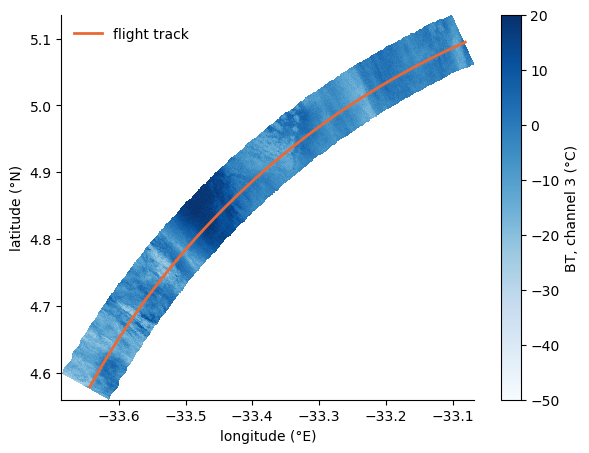

In [8]:
t = slice('2024-08-25T12:30', '2024-08-25T12:35')
pbg = campaign.pushbroom(t, channels=3, georef=True)
track = campaign.load_nav(t).sel(time=t)

fig, ax = plt.subplots(figsize=(7, 5))
lons, lats = pbg['lons'][::2, ::2], pbg['lats'][::2, ::2]
m = ax.pcolormesh(lons, lats, pbg['BT_2D'].sel(band=3)[::2, ::2][:-1, :-1],
                  cmap='Blues', vmin=-50, vmax=20, rasterized=True)
ax.plot(track['lon'], track['lat'], color='#eb6834', linewidth=2, label='flight track')
fig.colorbar(m, label='BT, channel 3 (°C)')
ax.set(xlabel='longitude (°E)', ylabel='latitude (°N)', aspect='equal')
ax.legend(frameon=False, loc='upper left');